## Column Name	Description
#### InvoiceNo:
 A unique identifier for each sales transaction (invoice).
#### StockCode:	
The code representing the product stock-keeping unit (SKU).
#### Description:	
A brief description of the product.
#### Quantity
The number of units of the product sold in the transaction.
#### InvoiceDate
The date and time when the sale was recorded.
#### UnitPrice
The price per unit of the product in the transaction currency.
#### CustomerID
A unique identifier for each customer.
#### Country	
The customer's country.
#### Discount	
The discount applied to the transaction, if any.
#### PaymentMethod
The method of payment used for the transaction (e.g., PayPal, Bank Transfer).
#### ShippingCost
The cost of shipping for the transaction.
#### Category	
The category to which the product belongs (e.g., Electronics, Apparel).
#### SalesChannel	
The channel through which the sale was made (e.g., Online, In-store).
#### eturnStatus	
Indicates whether the item was returned or not.
#### ShipmentProvider	
The provider responsible for delivering the order (e.g., UPS, FedEx).
#### WarehouseLocation	
The warehouse location from which the order was fulfilled.
#### OrderPriority	
The priority level of the order (e.g., High, Medium, Low).

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#Lo primero que nos interesá es conocer parte de la estructura básica de nuestra info
df=pd.read_csv("online_sales_dataset.csv")
#columnas que tengo y filas
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Discount,PaymentMethod,ShippingCost,Category,SalesChannel,ReturnStatus,ShipmentProvider,WarehouseLocation,OrderPriority
0,221958,SKU_1964,White Mug,38,2020-01-01 00:00,1.71,37039.0,Australia,0.470000,Bank Transfer,10.79,Apparel,In-store,Not Returned,UPS,London,Medium
1,771155,SKU_1241,White Mug,18,2020-01-01 01:00,41.25,19144.0,Spain,0.190000,paypall,9.51,Electronics,Online,Not Returned,UPS,Rome,Medium
2,231932,SKU_1501,Headphones,49,2020-01-01 02:00,29.11,50472.0,Germany,0.350000,Bank Transfer,23.03,Electronics,Online,Returned,UPS,Berlin,High
3,465838,SKU_1760,Desk Lamp,14,2020-01-01 03:00,76.68,96586.0,Netherlands,0.140000,paypall,11.08,Accessories,Online,Not Returned,Royal Mail,Rome,Low
4,359178,SKU_1386,USB Cable,-30,2020-01-01 04:00,-68.11,NaN,United Kingdom,1.501433,Bank Transfer,NaN,Electronics,In-store,Not Returned,FedEx,NaN,Medium


In [3]:
#tipos de datos y faltantes 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49782 entries, 0 to 49781
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   InvoiceNo          49782 non-null  int64  
 1   StockCode          49782 non-null  object 
 2   Description        49782 non-null  object 
 3   Quantity           49782 non-null  int64  
 4   InvoiceDate        49782 non-null  object 
 5   UnitPrice          49782 non-null  float64
 6   CustomerID         44804 non-null  float64
 7   Country            49782 non-null  object 
 8   Discount           49782 non-null  float64
 9   PaymentMethod      49782 non-null  object 
 10  ShippingCost       47293 non-null  float64
 11  Category           49782 non-null  object 
 12  SalesChannel       49782 non-null  object 
 13  ReturnStatus       49782 non-null  object 
 14  ShipmentProvider   49782 non-null  object 
 15  WarehouseLocation  46297 non-null  object 
 16  OrderPriority      497

In [4]:
#estadísticos de las variables numéricas
df.describe()

,InvoiceNo,Quantity,UnitPrice,CustomerID,Discount,ShippingCost
count,49782.000000,49782.000000,49782.000000,44804.000000,49782.000000,47293.000000
mean,550681.239946,22.372343,47.537862,55032.871775,0.275748,17.494529
std,260703.009944,17.917774,33.479510,25913.660157,0.230077,7.220557
min,100005.000000,-50.000000,-99.980000,10001.000000,0.000000,5.000000
25%,324543.000000,11.000000,23.592500,32750.750000,0.130000,11.220000
50%,552244.000000,23.000000,48.920000,55165.000000,0.260000,17.500000
75%,776364.000000,37.000000,74.610000,77306.250000,0.380000,23.720000
max,999997.000000,49.000000,100.000000,99998.000000,1.999764,30.000000


In [5]:
df.shape

(49782, 17)

In [6]:
df.isnull().sum()

InvoiceNo               0
StockCode               0
Description             0
Quantity                0
InvoiceDate             0
UnitPrice               0
CustomerID           4978
Country                 0
Discount                0
PaymentMethod           0
ShippingCost         2489
Category                0
SalesChannel            0
ReturnStatus            0
ShipmentProvider        0
WarehouseLocation    3485
OrderPriority           0
dtype: int64

# Numéricas 

# Empezaré a hacer boxplots e histogramas para cada variable y así poder saber como tratarla

    VARIABLE OBJETIVO "Quantity"

# AYUDAAAAA

In [7]:
df["Quantity"].isnull().sum()

0

Text(0.5, 1.0, 'Distribución de la variable objetivo')

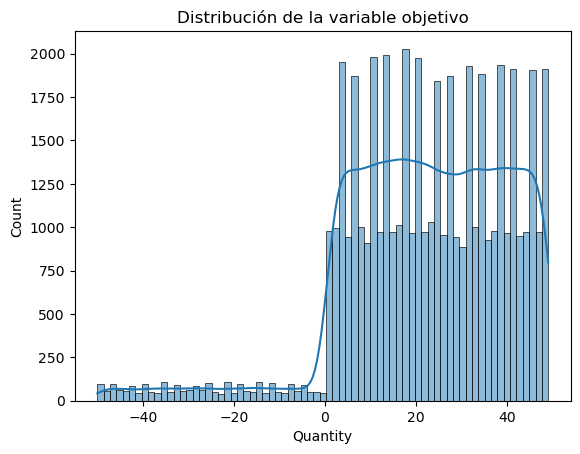

In [8]:
sns.histplot(df["Quantity"], kde=True)
plt.title("Distribución de la variable objetivo")

<Axes: ylabel='Quantity'>

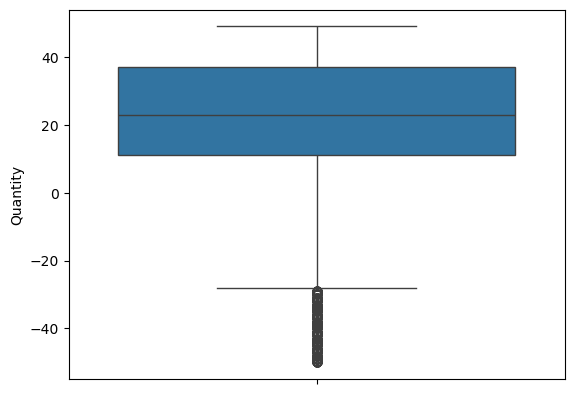

In [9]:
sns.boxplot(df["Quantity"])


In [10]:
#Hago un conteo de las negativas ya que me preocupa esto tanto como outliers como en distribución
df[df["Quantity"] < 0]["Quantity"].count()

2489

In [11]:
df = df.drop(df[df["Quantity"] < 0].index)


In [21]:
#vuelvo a revisar si ya no hay negativos, y vuelvo a checar distibuciones
df[df["Quantity"] < 0]["Quantity"].count()

0

Text(0.5, 1.0, 'Distribución de la variable objetivo')

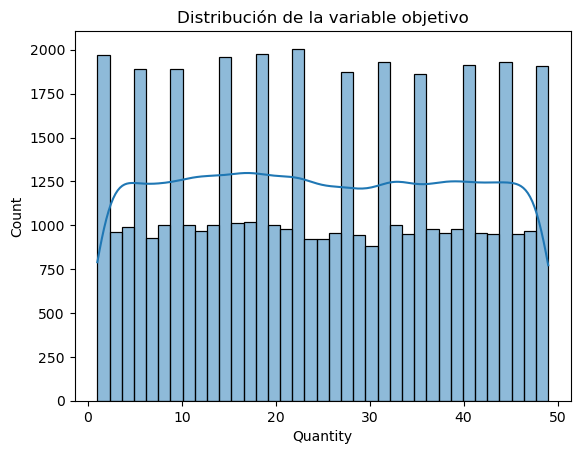

In [22]:
sns.histplot(df["Quantity"], kde=True)
plt.title("Distribución de la variable objetivo")

<Axes: ylabel='Quantity'>

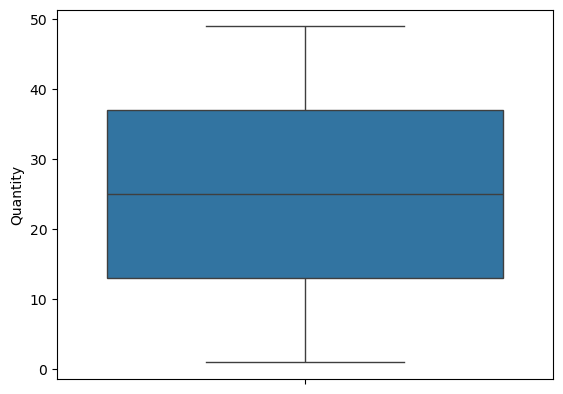

In [23]:
sns.boxplot(df["Quantity"])


    SOLUCIONADO


    VARIABLE "UnitPrice"

In [12]:
df["UnitPrice"].isnull().sum()

0

Text(0.5, 1.0, 'Distribución del Precio por Unidad ')

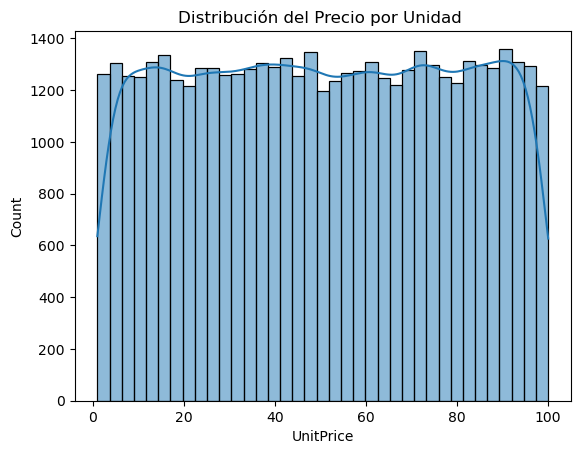

In [13]:
sns.histplot(df["UnitPrice"], kde=True)
plt.title("Distribución del Precio por Unidad ")

<Axes: ylabel='UnitPrice'>

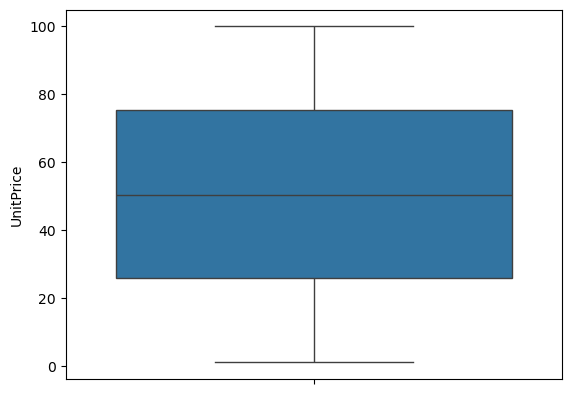

In [14]:
sns.boxplot(df["UnitPrice"])

# Pendiente (Relacionado con la cantidad vendida)(Quantity)

    VARIEABLE "CoustomerID"

In [15]:
df["CustomerID"] = df["CustomerID"].fillna("Desconocido")

In [16]:
df["CustomerID"].value_counts()

CustomerID
Desconocido    2489
53125.0           6
63229.0           5
81806.0           5
12591.0           5
               ... 
41722.0           1
15639.0           1
28212.0           1
88671.0           1
28879.0           1
Name: count, Length: 35390, dtype: int64

    VARIABLE "Discount"

In [17]:
df["Discount"].isnull().sum()

0

Text(0.5, 1.0, 'Distribución de la variable Discount')

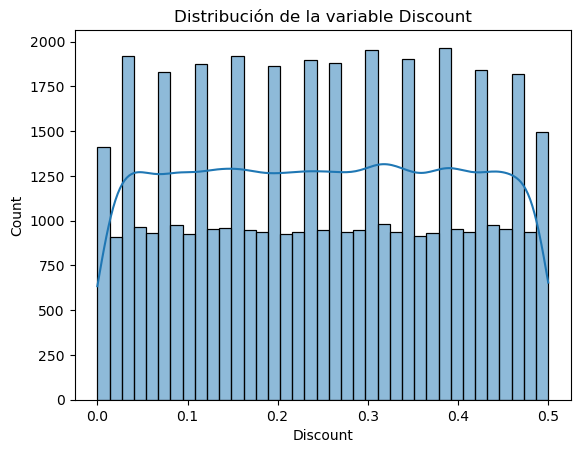

In [18]:
sns.histplot(df["Discount"],kde=True)
plt.title("Distribución de la variable Discount")

<Axes: ylabel='Discount'>

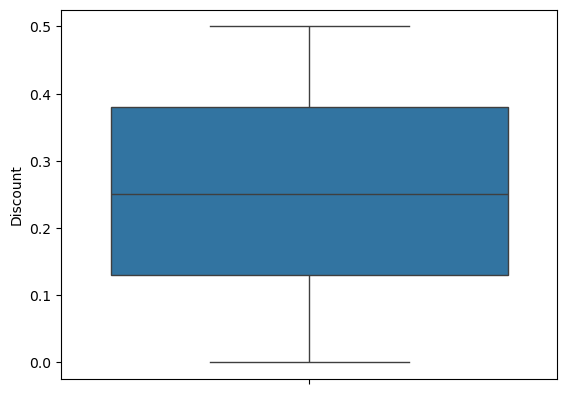

In [19]:
sns.boxplot(df["Discount"])

In [27]:
df["Discount"].value_counts()

Discount
0.31    1057
0.34    1012
0.39    1003
0.49    1000
0.32     982
0.44     977
0.09     975
0.16     970
0.03     967
0.05     967
0.38     963
0.23     963
0.14     961
0.08     956
0.13     955
0.12     955
0.45     955
0.20     954
0.04     952
0.26     952
0.40     951
0.29     950
0.17     948
0.25     948
0.15     948
0.22     937
0.18     936
0.33     936
0.48     935
0.41     935
0.46     934
0.28     934
0.37     932
0.24     932
0.27     930
0.43     929
0.06     929
0.21     928
0.01     926
0.10     923
0.11     920
0.36     915
0.42     913
0.19     912
0.02     911
0.30     895
0.35     890
0.47     887
0.07     874
0.50     493
0.00     486
Name: count, dtype: int64

In [ ]:
df["ShippingCost"].isnull().sum()

2489

Text(0.5, 1.0, 'Distribución de ShippingCoast')

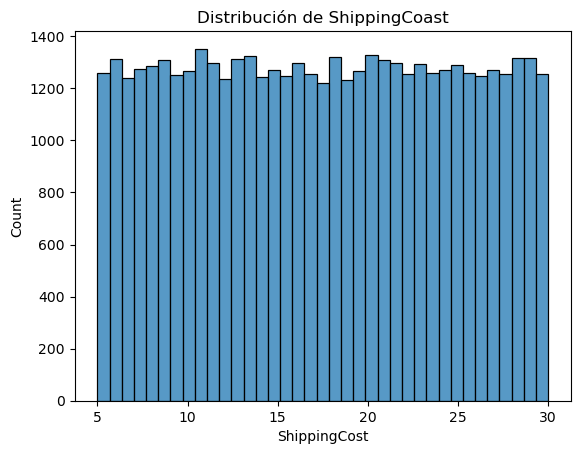

In [ ]:
sns.histplot(df["ShippingCost"])
plt.title("Distribución de ShippingCoast")

<Axes: ylabel='ShippingCost'>

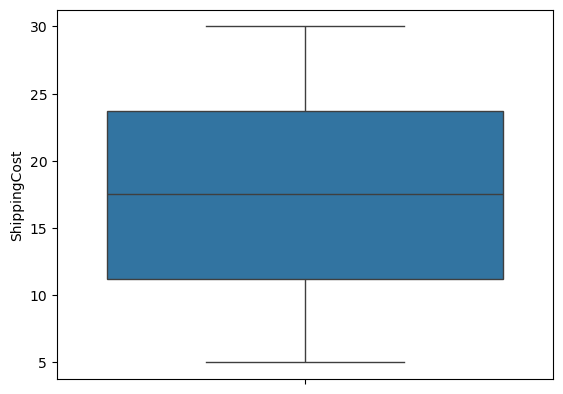

In [ ]:
sns.boxplot(df["ShippingCost"])

# Categóricas

    VARIABLE Country

In [ ]:
df["Country"].isnull().sum()

0

In [ ]:
df["Country"].value_counts()


Country
France            4230
Sweden            4211
Germany           4182
United Kingdom    4180
Netherlands       4173
Belgium           4170
Portugal          4163
Norway            4157
Australia         4110
Spain             4100
United States     4058
Italy             4048
Name: count, dtype: int64

    VARIABLE PaymentMethod

In [ ]:
df["PaymentMethod"].isnull().sum()

0

In [ ]:
df["PaymentMethod"].value_counts()

PaymentMethod
Bank Transfer    16747
Credit Card      16530
paypall          16505
Name: count, dtype: int64

    VARIABLE Category

In [ ]:
df["Category"].isnull().sum()

0

In [ ]:
df["Category"].value_counts()

Category
Furniture      10084
Accessories     9975
Electronics     9931
Stationery      9928
Apparel         9864
Name: count, dtype: int64

    VARIABLE OrderPriority

In [ ]:
df["OrderPriority"].isnull().sum()

0

In [ ]:
df["OrderPriority"].value_counts()

OrderPriority
Medium    16678
High      16562
Low       16542
Name: count, dtype: int64

    VARIABLE Description

In [ ]:
df["Description"].isnull().sum()

0

In [ ]:
df["Description"].value_counts()

Description
Wall Clock        4617
USB Cable         4580
Headphones        4555
Backpack          4550
Desk Lamp         4545
White Mug         4536
Office Chair      4522
Blue Pen          4509
T-shirt           4466
Notebook          4454
Wireless Mouse    4448
Name: count, dtype: int64

    VARIABLE Sales Channel

In [ ]:
df["SalesChannel"].isnull().sum()

0

In [ ]:
df["SalesChannel"].value_counts()

SalesChannel
Online      25051
In-store    24731
Name: count, dtype: int64

    VARIABLE ReturnStatus

In [ ]:
df["ReturnStatus"].isnull().sum()

0

In [ ]:
df["ReturnStatus"].value_counts()

ReturnStatus
Not Returned    44888
Returned         4894
Name: count, dtype: int64

    VARIABLE ShipmentProvider

In [ ]:
df["ShipmentProvider"].isnull().sum()

0

In [ ]:
df["ShipmentProvider"].value_counts()

ShipmentProvider
FedEx         12501
UPS           12433
DHL           12425
Royal Mail    12423
Name: count, dtype: int64

    VARIABLE WarehouseLocation

In [ ]:
df["WarehouseLocation"].isnull().sum()

3485

In [ ]:
df["WarehouseLocation"].value_counts()

WarehouseLocation
Amsterdam    9458
London       9230
Rome         9226
Berlin       9210
Paris        9173
Name: count, dtype: int64

In [ ]:
df["WarehouseLocation"] = df["WarehouseLocation"].fillna("Desconocido")

In [ ]:
df["WarehouseLocation"].value_counts()

WarehouseLocation
Amsterdam      9458
London         9230
Rome           9226
Berlin         9210
Paris          9173
Desconocido    3485
Name: count, dtype: int64

## Transformación general
Luego de revisar una por una, podemos validar la decisión de transformarlas a one hot encoding (la cantidad de categorías es suficiente), por lo que podemos aplicarle el one hot.

In [ ]:
cat_cols = ["PaymentMethod", "SalesChannel", "Category", "ReturnStatus",
            "ShipmentProvider", "WarehouseLocation", "OrderPriority", "Country","Description"]

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [ ]:
df_encoded.head()

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Discount,ShippingCost,PaymentMethod_Credit Card,PaymentMethod_paypall,...,Description_Blue Pen,Description_Desk Lamp,Description_Headphones,Description_Notebook,Description_Office Chair,Description_T-shirt,Description_USB Cable,Description_Wall Clock,Description_White Mug,Description_Wireless Mouse
0,221958,SKU_1964,38,2020-01-01 00:00,1.71,37039.0,0.470000,10.79,False,False,...,False,False,False,False,False,False,False,False,True,False
1,771155,SKU_1241,18,2020-01-01 01:00,41.25,19144.0,0.190000,9.51,False,True,...,False,False,False,False,False,False,False,False,True,False
2,231932,SKU_1501,49,2020-01-01 02:00,29.11,50472.0,0.350000,23.03,False,False,...,False,False,True,False,False,False,False,False,False,False
3,465838,SKU_1760,14,2020-01-01 03:00,76.68,96586.0,0.140000,11.08,False,True,...,False,True,False,False,False,False,False,False,False,False
4,359178,SKU_1386,-30,2020-01-01 04:00,-68.11,NaN,1.501433,NaN,False,False,...,False,False,False,False,False,False,True,False,False,False


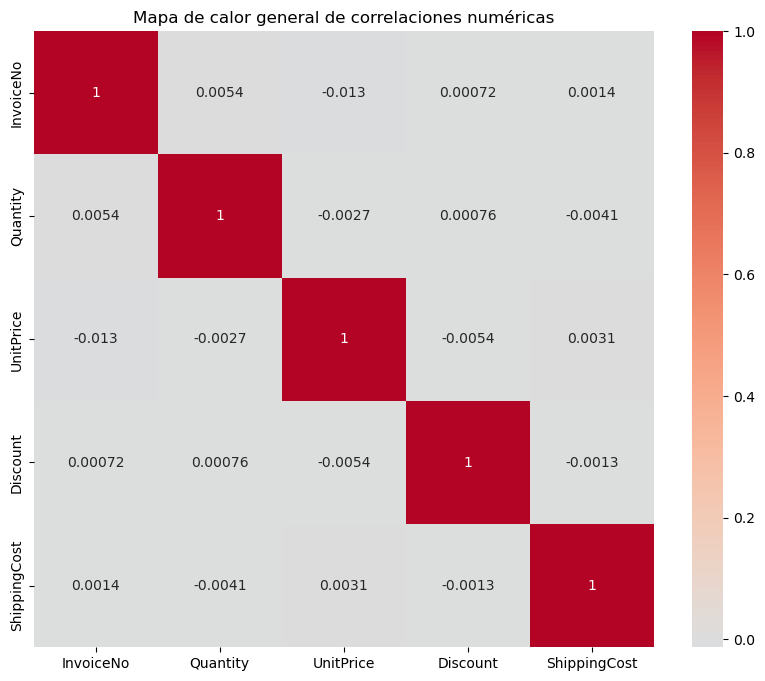

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo columnas numéricas
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Mapa de calor general de correlaciones numéricas")
plt.show()
